This is a small implementation with visuals of my understanding on linear regression. Here I will try to predict the salary of a person by his/her years experience....

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
%matplotlib widget

In [49]:
data = np.loadtxt('Salary_dataset.csv', delimiter=',' , skiprows=1)
x_train = data[:,1]
y_train = data[:, 2]

In [50]:
b = 30000

def compute_model_output(x, w):
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

In [51]:
def compute_cost_function(x, y, w):
    m = x.shape[0]
    J_wb_temp = np.zeros(m)
    f_wb = compute_model_output(x, w)
    for i in range(m):
        J_wb_temp[i] = (f_wb[i] - y[i])**2
    J_wb = np.mean(J_wb_temp)/2
    return J_wb

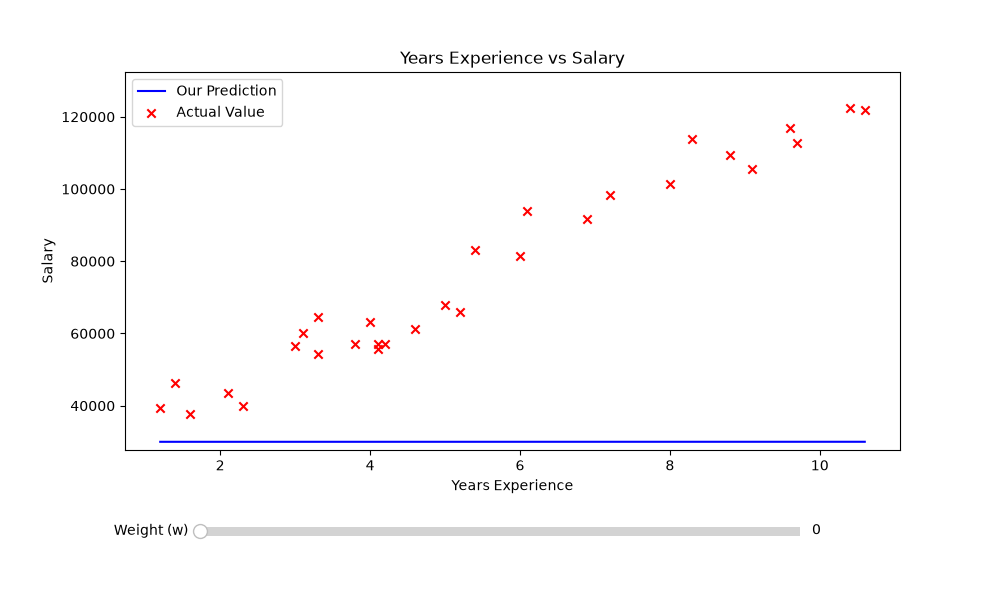

In [52]:
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.25)
f_wb_temp = compute_model_output(x_train, 1)
line, = ax.plot(x_train, f_wb_temp, c="b", label="Our Prediction")
ax.scatter(x_train, y_train, c="r", marker="x", label="Actual Value")
ax.set_xlabel("Years Experience")
ax.set_ylabel("Salary")
ax.set_title("Years Experience vs Salary")
ax.legend()
ax.set_ylim([y_train.min() - 10000, y_train.max() + 10000])
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider_w = Slider(ax_slider, 'Weight (w)', 0, 20000, valinit=1, valstep=10)
def update_graph(val):
    w_val = slider_w.val
    f_wb_temp = compute_model_output(x_train, w_val)
    line.set_ydata(f_wb_temp)
    fig.canvas.draw_idle()
slider_w.on_changed(update_graph)
plt.show()